# 0. AI허브 사전학습 모델 패키지 분석

EDA / 마스크 변환 완료 후 발견한 **DeepLabV3+ 사전학습 가중치**의 사용 가능성을 검토합니다.

1. **README / 설명 파일** — 클래스 매핑, 입력 해상도, 정규화 통계
2. **가중치 키 구조** — 백본(Xception / ResNet / DRN) + 최종 분류 헤드의 클래스 수
3. **`test*.py` 추론 스크립트** — 진입점 / 입력 포맷

### 0-1. 공통 설정 & 패키지 ROOT 확인

In [2]:
from pathlib import Path
import torch

ROOT = Path(r'D:\02.study\part4_wj\Battery\Battery_Project\pretrained_aihub')
assert ROOT.exists(), f'패키지 경로 없음: {ROOT}'
print(f'사전학습 패키지 ROOT: {ROOT}')
print(f'하위 폴더: {[p.name for p in ROOT.iterdir() if p.is_dir()]}')

사전학습 패키지 ROOT: D:\02.study\part4_wj\Battery\Battery_Project\pretrained_aihub
하위 폴더: ['1.모델소스코드', '2.AI학습모델파일']


> 셀 1개에 임포트와 ROOT 정의만 둡니다. 이후 모든 셀이 이 변수를 재사용합니다.

## 1. README / 설명 파일 스캔

### 1-1. 문서 파일 목록 + 작은 텍스트는 본문 일부 출력

In [3]:
DOC_EXTS = {'.md', '.txt', '.rst', '.pdf', '.docx', '.hwp', '.html'}
docs = [p for p in ROOT.rglob('*') if p.is_file() and p.suffix.lower() in DOC_EXTS]

print(f'문서 파일 총 {len(docs)}개')
for p in docs[:30]:
    print(f'  - {p.relative_to(ROOT)} ({p.stat().st_size:,} bytes)')

문서 파일 총 1개
  - 1.모델소스코드\모델1_DeepLabv3\pytorch-deeplab-xception-eval\README.md (3,287 bytes)


In [4]:
# 8KB 미만 텍스트 문서는 첫 1,500자 미리보기
for p in docs:
    if p.suffix.lower() in {'.md', '.txt', '.rst'} and p.stat().st_size < 8000:
        print(f'\n--- {p.relative_to(ROOT)} ---')
        for enc in ('utf-8', 'cp949', 'utf-16'):
            try:
                print(p.read_text(encoding=enc)[:1500])
                break
            except UnicodeDecodeError:
                continue


--- 1.모델소스코드\모델1_DeepLabv3\pytorch-deeplab-xception-eval\README.md ---
# pytorch-deeplab-xception

**Update on 2018/12/06. Provide model trained on VOC and SBD datasets.**  

**Update on 2018/11/24. Release newest version code, which fix some previous issues and also add support for new backbones and multi-gpu training. For previous code, please see in `previous` branch**  

### TODO
- [x] Support different backbones
- [x] Support VOC, SBD, Cityscapes and COCO datasets
- [x] Multi-GPU training



| Backbone  | train/eval os  |mIoU in val |Pretrained Model|
| :-------- | :------------: |:---------: |:--------------:|
| ResNet    | 16/16          | 78.43%     | [google drive](https://drive.google.com/open?id=1NwcwlWqA-0HqAPk3dSNNPipGMF0iS0Zu) |
| MobileNet | 16/16          | 70.81%     | [google drive](https://drive.google.com/open?id=1G9mWafUAj09P4KvGSRVzIsV_U5OqFLdt) |
| DRN       | 16/16          | 78.87%     | [google drive](https://drive.google.com/open?id=131gZN_dKEXO79NknIQazPJ-4

## 2. 가중치 파일 메타정보

체크포인트가 dict 형태인지, `state_dict` 외에 어떤 키가 함께 저장됐는지 확인합니다.

### 2-1. 체크포인트 로드 & 최상위 키 확인

In [5]:
PT_PATH = ROOT / '2.AI학습모델파일' / 'weights' / '모델2batteryrgb.pt'
print(f'경로: {PT_PATH}')
print(f'존재: {PT_PATH.exists()}  크기: {PT_PATH.stat().st_size / 1024**2:.1f} MB')

ckpt = torch.load(str(PT_PATH), map_location='cpu', weights_only=False)
print(f'타입: {type(ckpt).__name__}')

if isinstance(ckpt, dict):
    print(f'최상위 키: {list(ckpt.keys())}')
    state_dict = ckpt.get('state_dict') or ckpt.get('model') or ckpt
else:
    state_dict = ckpt

print(f'state_dict 키 개수: {len(state_dict)}')

경로: D:\02.study\part4_wj\Battery\Battery_Project\pretrained_aihub\2.AI학습모델파일\weights\모델2batteryrgb.pt
존재: True  크기: 466.7 MB
타입: dict
최상위 키: ['epoch', 'state_dict', 'optimizer', 'best_pred']
state_dict 키 개수: 398


## 3. state_dict 키 구조 (백본 & 모듈 prefix)

### 3-1. 앞/뒤 키 샘플 + 모듈 prefix

In [6]:
keys = list(state_dict.keys())

print('[앞 10개]')
for k in keys[:10]:
    shape = tuple(state_dict[k].shape) if hasattr(state_dict[k], 'shape') else '?'
    print(f'  {k:60s} {shape}')

print('\n[뒤 8개]')
for k in keys[-8:]:
    shape = tuple(state_dict[k].shape) if hasattr(state_dict[k], 'shape') else '?'
    print(f'  {k:60s} {shape}')

prefixes = sorted({k.split('.')[0] for k in keys})
print(f'\n모듈 prefix 후보: {prefixes}')

[앞 10개]
  backbone.layer0.0.weight                                     (16, 3, 7, 7)
  backbone.layer0.1.weight                                     (16,)
  backbone.layer0.1.bias                                       (16,)
  backbone.layer0.1.running_mean                               (16,)
  backbone.layer0.1.running_var                                (16,)
  backbone.layer0.1.num_batches_tracked                        ()
  backbone.layer1.0.weight                                     (16, 16, 3, 3)
  backbone.layer1.1.weight                                     (16,)
  backbone.layer1.1.bias                                       (16,)
  backbone.layer1.1.running_mean                               (16,)

[뒤 8개]
  decoder.last_conv.4.weight                                   (256, 256, 3, 3)
  decoder.last_conv.5.weight                                   (256,)
  decoder.last_conv.5.bias                                     (256,)
  decoder.last_conv.5.running_mean                          

> 출력 예시: `prefix = ['aspp', 'backbone', 'decoder']` → DeepLabV3+ 표준 구조(Backbone + ASPP + Decoder) 확인.

## 4. 분류 헤드 / 출력 클래스 수 추정

마지막 conv의 `out_channels`이 클래스 수다. 우리 데이터는 3종(`background / Pollution / Damaged`)이므로 비교가 필요합니다.

### 4-1. 헤드 후보 키 + 클래스 수 판정

In [8]:
HEAD_KW = ('last', 'classifier', 'final', 'pred', 'head', 'cls')
head_keys = [k for k in keys if any(w in k.lower() for w in HEAD_KW)]

print('분류 헤드 추정 키 (앞 8):')
for k in head_keys[:8]:
    shape = tuple(state_dict[k].shape) if hasattr(state_dict[k], 'shape') else '?'
    print(f'  {k}  {shape}')

# 마지막 1x1 conv의 out_channels = 클래스 수
last_conv = [k for k in head_keys if k.endswith('.weight') and state_dict[k].ndim == 4][-1]
num_classes = state_dict[last_conv].shape[0]
print(f'\n→ 최종 conv: {last_conv}  shape={tuple(state_dict[last_conv].shape)}')
print(f'→ 추정 클래스 수: {num_classes}  (실제 데이터: 3 = bg/Pollution/Damaged)')

분류 헤드 추정 키 (앞 8):
  decoder.last_conv.0.weight  (256, 304, 3, 3)
  decoder.last_conv.1.weight  (256,)
  decoder.last_conv.1.bias  (256,)
  decoder.last_conv.1.running_mean  (256,)
  decoder.last_conv.1.running_var  (256,)
  decoder.last_conv.1.num_batches_tracked  ()
  decoder.last_conv.4.weight  (256, 256, 3, 3)
  decoder.last_conv.5.weight  (256,)

→ 최종 conv: decoder.last_conv.8.weight  shape=(4, 256, 1, 1)
→ 추정 클래스 수: 4  (실제 데이터: 3 = bg/Pollution/Damaged)


### 4-2. 클래스 수 판정 결과 및 결정

**판정 결과**

- 최종 conv: `decoder.last_conv.8.weight` shape = `(4, 256, 1, 1)`
- 사전학습 모델 출력 클래스 수: **4**
- 우리 데이터 클래스 수: **3** (`background / Pollution / Damaged`)
- **불일치** → 가중치를 그대로 로드해 추론할 수 없음

## 5. 추론 스크립트(`test*.py`) 진입점 미리보기

### 5-1. 스크립트별 상단 25줄 + main 위치

In [9]:
SRC = ROOT / '1.모델소스코드' / '모델1_DeepLabv3' / 'pytorch-deeplab-xception-eval'

for tf in sorted(SRC.glob('test*.py')):
    print(f'\n--- {tf.name} ({tf.stat().st_size:,} bytes) ---')
    lines = tf.read_text(encoding='utf-8', errors='replace').split('\n')
    for i, l in enumerate(lines[:25], 1):
        print(f'  {i:3d}| {l}')
    for i, l in enumerate(lines, 1):
        if '__main__' in l:
            print(f'  (main entry at line {i})')
            break


--- test.py (9,370 bytes) ---
    1| import argparse
    2| import os
    3| import time, calendar
    4| import numpy as np 
    5| import tqdm
    6| import torch
    7| 
    8| from torch.utils.data import DataLoader
    9| from PIL import Image
   10| from skimage.transform import resize
   11| from dataloaders.datasets import simple
   12| from modeling.deeplab import *
   13| from dataloaders.utils import get_pascal_labels
   14| from utils.metrics import Evaluator
   15| from logger import LoggerHelper
   16| 
   17| 
   18| class Tester(object):
   19|     def __init__(self, args, base_dir):
   20|         if not os.path.isfile(args.model):
   21|             raise RuntimeError("No checkpoint found at '{}'".format(args.model))
   22|         
   23|         self.args = args
   24|         self.color_map = get_pascal_labels()
   25| 
  (main entry at line 196)

--- test2.py (10,285 bytes) ---
    1| import argparse
    2| import os
    3| import time, calendar
    4| import num

### 5-2. main entry 영역 (모델 생성 인자 확인)

In [11]:
TEST_PY = SRC / 'test.py'
lines = TEST_PY.read_text(encoding='utf-8', errors='replace').split('\n')

# main entry 주변 ±30줄 + DeepLab( 호출 부분 검색
for i, l in enumerate(lines, 1):
    if 'DeepLab(' in l or 'num_classes' in l or 'add_argument' in l[:40]:
        print(f'  {i:3d}| {l}')

   30|         simple.SimpleSegmentation.NUM_CLASSES = args.num_classes
   31|         self.num_classes = simple.SimpleSegmentation.NUM_CLASSES
   37|         self.model = DeepLab(num_classes=self.num_classes,
   55|         self.evaluator = Evaluator(self.num_classes)
   66|         for i in range(self.num_classes):
  152|     parser.add_argument('--num-classes', type=int, 
  156|     parser.add_argument('--gpu-ids', type=str, default='0',
  159|     parser.add_argument('--backbone', default='drn', 
  161|     parser.add_argument('--out-stride', type=int, default=16,
  163|     parser.add_argument('--model', type=str, 
  167|     parser.add_argument('--save_dir', type=str, default='logs/result',
  169|     parser.add_argument('--base_dir', type=str, 
  175|     parser.add_argument('--workers', type=int, default=1,
  178|     parser.add_argument('--crop-size', type=int, 
  182|     parser.add_argument('--crop', type=str, default='slide',
  184|     parser.add_argument('--offset_width',

### 5-3. dataloader (입력 해상도 / 정규화)

In [12]:
SIMPLE_PY = SRC / 'dataloaders' / 'datasets' / 'simple.py'
if SIMPLE_PY.exists():
    lines = SIMPLE_PY.read_text(encoding='utf-8', errors='replace').split('\n')
    print(f'--- {SIMPLE_PY.name} ({len(lines)} lines) ---')
    for i, l in enumerate(lines, 1):
        # 해상도, normalize, transforms 관련 라인만 발췌
        if any(kw in l for kw in ('resize', 'Resize', 'crop', 'Crop',
                                    'mean', 'std', 'Normalize',
                                    'self.size', 'self.crop', '__getitem__', 'def __init__')):
            print(f'  {i:3d}| {l}')
else:
    print(f'없음: {SIMPLE_PY}')

--- simple.py (191 lines) ---
   15|     def __init__(self,
   45|             frame_lines = os.listdir(os.path.join(self._image_dir, splt))
   47|             mask_lines = os.listdir(os.path.join(self._cat_dir, splt))
   75|     def __getitem__(self, index):
   85|                 if self.args.crop == "slide":
   87|                 elif self.args.crop == "random":
   88|                     return self.transform_random_crop(sample)
   90|                     return self.transform_fixed_resize(sample)
  101|             tr.RandomScaleCrop(base_size=self.args.base_size, crop_size=self.args.crop_size),
  103|             tr.Normalize(mean=(0.485, 0.456, 0.406), std=(0.229, 0.224, 0.225)),
  110|             tr.FixScaleCrop(crop_size=self.args.crop_size),
  111|             tr.Normalize(mean=(0.485, 0.456, 0.406), std=(0.229, 0.224, 0.225)),
  116|     def transform_fixed_resize(self, sample):
  118|             tr.FixedResize(size=self.args.crop_size),
  119|             tr.Normalize(me

## 6. 모델 인스턴스 생성 + 가중치 로드

원작자의 코드를 그대로 활용하기 위해 `pretrained_aihub/1.모델소스코드/.../pytorch-deeplab-xception-eval` 경로를
`sys.path`에 추가하여 `modeling.deeplab.DeepLab` 클래스를 import한다.

- 백본: DRN / output_stride: 16 / num_classes: 4
- state_dict 키 일치 여부를 `load_state_dict(strict=False)`의 missing/unexpected 출력으로 확인

### 6-1. DeepLab 모델 + 가중치 로드

In [14]:
import sys
SRC_ROOT = ROOT / '1.모델소스코드' / '모델1_DeepLabv3' / 'pytorch-deeplab-xception-eval'
if str(SRC_ROOT) not in sys.path:
    sys.path.insert(0, str(SRC_ROOT))

# ── DRN 백본의 ImageNet pretrained 다운로드 차단 ──
# AI허브 체크포인트에 backbone.* 가중치가 모두 들어있어 어차피 덮어쓰여짐.
# 네트워크 차단 환경에서도 동작하도록 monkey-patch.
from modeling.backbone import drn
_orig_drn_d_54 = drn.drn_d_54
drn.drn_d_54 = lambda BatchNorm, pretrained=False: _orig_drn_d_54(BatchNorm, pretrained=False)

NUM_CLASSES = 4   # 가중치와 일치 (체크포인트 분석 결과)
model = DeepLab(num_classes=NUM_CLASSES, backbone='drn', output_stride=16,
                sync_bn=False, freeze_bn=True)

result = model.load_state_dict(state_dict, strict=False)
print(f'Missing keys: {len(result.missing_keys)}  (앞 5: {result.missing_keys[:5]})')
print(f'Unexpected keys: {len(result.unexpected_keys)}  (앞 5: {result.unexpected_keys[:5]})')

model.eval()
print('\n모델 준비 완료 (eval 모드)')

Missing keys: 0  (앞 5: [])
Unexpected keys: 0  (앞 5: [])

모델 준비 완료 (eval 모드)


In [15]:
print(drn.__file__)

D:\02.study\part4_wj\Battery\Battery_Project\pretrained_aihub\1.모델소스코드\모델1_DeepLabv3\pytorch-deeplab-xception-eval\modeling\backbone\drn.py


## 9. 단일 이미지 추론 동작 검증

### 9-1. 전처리 함수 + 결함 이미지 1장 선택

In [24]:
import numpy as np
from PIL import Image
import torchvision.transforms as T
import glob

IMG_SIZE = 513
preprocess = T.Compose([
    T.Resize((IMG_SIZE, IMG_SIZE)),
    T.ToTensor(),                                        # [0,1] HWC→CHW
    T.Normalize(mean=(0.485, 0.456, 0.406),              # ImageNet (셀 6-4)
                std=(0.229, 0.224, 0.225)),
])

# 결함 있는 이미지 후보 자동 탐색 (마스크 PNG에서 0이 아닌 픽셀 보유)
PROJECT = Path(r'D:\02.study\part4_wj\Battery\Battery_Project')
IMG_DIR   = PROJECT/'battery_image'
LBL_DIR   = PROJECT/'battery_label'
MASK_DIR  = PROJECT/'battery_mask'
SPLIT_DIR = PROJECT/'battery_splits'

assert MASK_DIR.exists(), f'경로 없음: {MASK_DIR}'
print(f'마스크 디렉터리: {MASK_DIR}  (파일 수: {len(list(MASK_DIR.glob("*.png")))})')

마스크 디렉터리: D:\02.study\part4_wj\Battery\Battery_Project\battery_mask  (파일 수: 249)


In [25]:
defect_samples = []
for mask_path in sorted(MASK_DIR.glob('*.png'))[:50]:
    m = np.array(Image.open(mask_path))
    if (m > 0).any():
        defect_samples.append(mask_path.stem)
    if len(defect_samples) >= 3:
        break

print(f'결함 샘플 후보: {defect_samples}')
SAMPLE = defect_samples[0]
print(f'→ 사용할 샘플: {SAMPLE}')

결함 샘플 후보: ['RGB_cell_cylindrical_0722_206', 'RGB_cell_cylindrical_0729_039', 'RGB_cell_cylindrical_0729_189']
→ 사용할 샘플: RGB_cell_cylindrical_0722_206


### 9-2. 추론 실행 + 출력 shape 확인

In [26]:
# 확장자 자동 탐지 (.jpg / .png / .jpeg 모두 대응)
candidates = list(IMG_DIR.glob(f'{SAMPLE}.*'))
assert candidates, f'이미지 없음: {SAMPLE}'
img_path = candidates[0]
print(f'이미지 경로: {img_path}')

img = Image.open(img_path).convert('RGB')
print(f'원본 이미지: {img.size}  (W, H)')

x = preprocess(img).unsqueeze(0)       # (1, 3, 513, 513)
print(f'전처리 후 텐서: {tuple(x.shape)}')

with torch.no_grad():
    logits = model(x)                  # (1, 4, 513, 513) 기대

print(f'출력 shape: {tuple(logits.shape)}')
print(f'출력 dtype: {logits.dtype}')
print(f'채널별 max activation: {logits[0].amax(dim=(1,2)).tolist()}')
print(f'채널별 min activation: {logits[0].amin(dim=(1,2)).tolist()}')

이미지 경로: D:\02.study\part4_wj\Battery\Battery_Project\battery_image\RGB_cell_cylindrical_0722_206.png
원본 이미지: (1920, 1080)  (W, H)
전처리 후 텐서: (1, 3, 513, 513)
출력 shape: (1, 4, 513, 513)
출력 dtype: torch.float32
채널별 max activation: [33.37898254394531, 1.9881291389465332, -2.516787528991699, -0.30915752053260803]
채널별 min activation: [-37.17318344116211, -116.99876403808594, -99.61705780029297, -89.06149291992188]


## 9-3. 4채널 활성화 시각화로 채널-클래스 매핑 추정

GT mask 고유값: [0 1]  (0=bg, 1=Pollution, 2=Damaged)


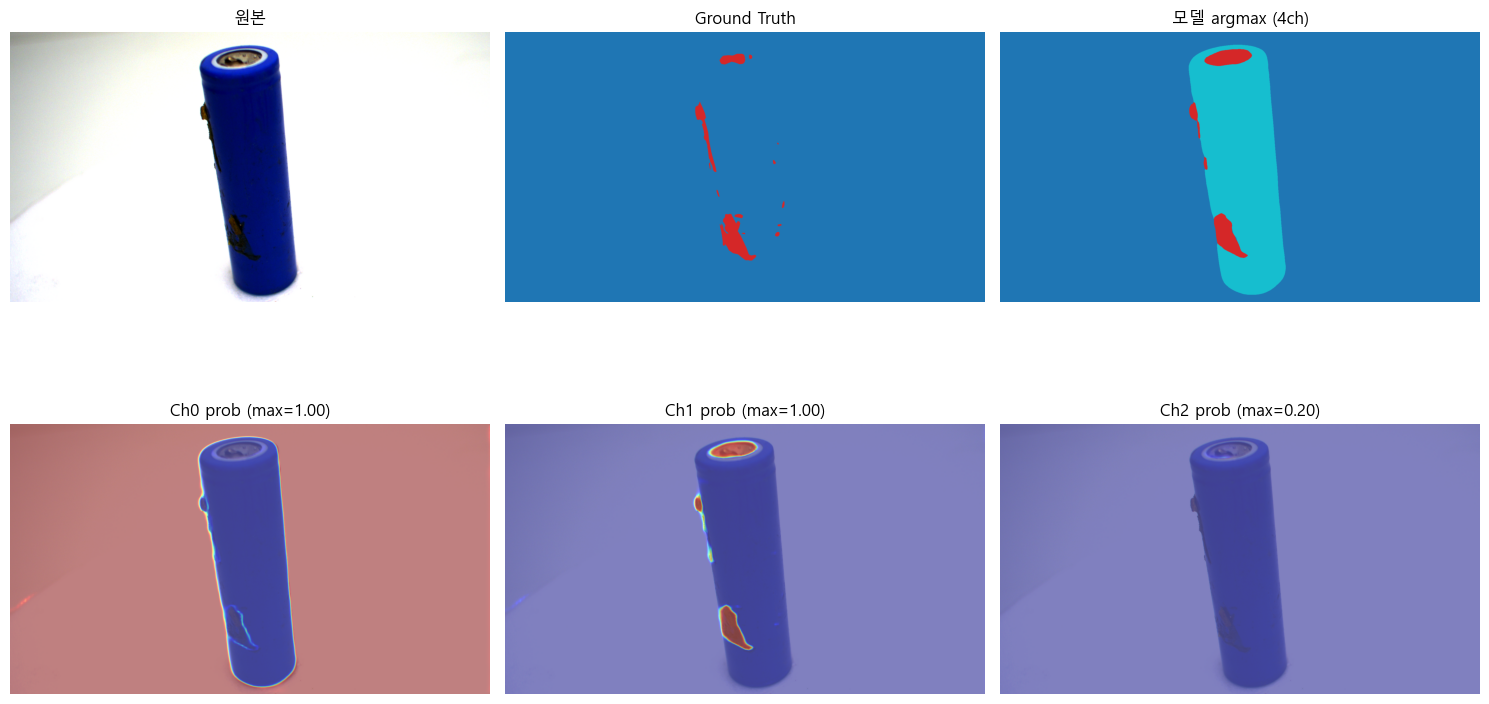

In [30]:
import matplotlib.pyplot as plt
import torch.nn.functional as F

# 한글 깨짐 마이너스 부호 깨짐 방지
plt.rcParams['font.family'] = 'Malgun Gothic'
plt.rcParams['axes.unicode_minus'] = False

# 원본 크기로 업샘플 (시각화 정합성)
orig_w, orig_h = img.size
logits_up = F.interpolate(logits, size=(orig_h, orig_w), mode='bilinear', align_corners=False)
probs = F.softmax(logits_up, dim=1)[0].cpu().numpy()   # (4, H, W)
argmax = logits_up[0].argmax(dim=0).cpu().numpy()      # (H, W)

# Ground truth 마스크
gt_mask = np.array(Image.open(MASK_DIR / f'{SAMPLE}.png'))
print(f'GT mask 고유값: {np.unique(gt_mask)}  (0=bg, 1=Pollution, 2=Damaged)')

# 시각화 (2x3 grid)
fig, axes = plt.subplots(2, 3, figsize=(15, 9))
axes[0, 0].imshow(img);                      axes[0, 0].set_title('원본')
axes[0, 1].imshow(gt_mask, cmap='tab10', vmin=0, vmax=3); axes[0, 1].set_title('Ground Truth')
axes[0, 2].imshow(argmax, cmap='tab10', vmin=0, vmax=3); axes[0, 2].set_title('모델 argmax (4ch)')
for i in range(4):
    ax = axes[1, i] if i < 3 else None
    if ax is None:
        break
    ax.imshow(img, alpha=0.5)
    ax.imshow(probs[i], cmap='jet', alpha=0.5, vmin=0, vmax=1)
    ax.set_title(f'Ch{i} prob (max={probs[i].max():.2f})')

for ax in axes.flat:
    ax.axis('off')
    
plt.tight_layout()
plt.show()

### 9-4. Damaged 라벨 샘플로 채널 3 검증

Damaged 샘플 후보: ['RGB_cell_cylindrical_0747_077', 'RGB_cell_cylindrical_0755_290', 'RGB_cell_cylindrical_0791_220']

[RGB_cell_cylindrical_0747_077] 채널별 max: [49.3548583984375, 0.8514970541000366, -1.6886868476867676, -0.1995553970336914]
GT 고유값: [0 1 2]


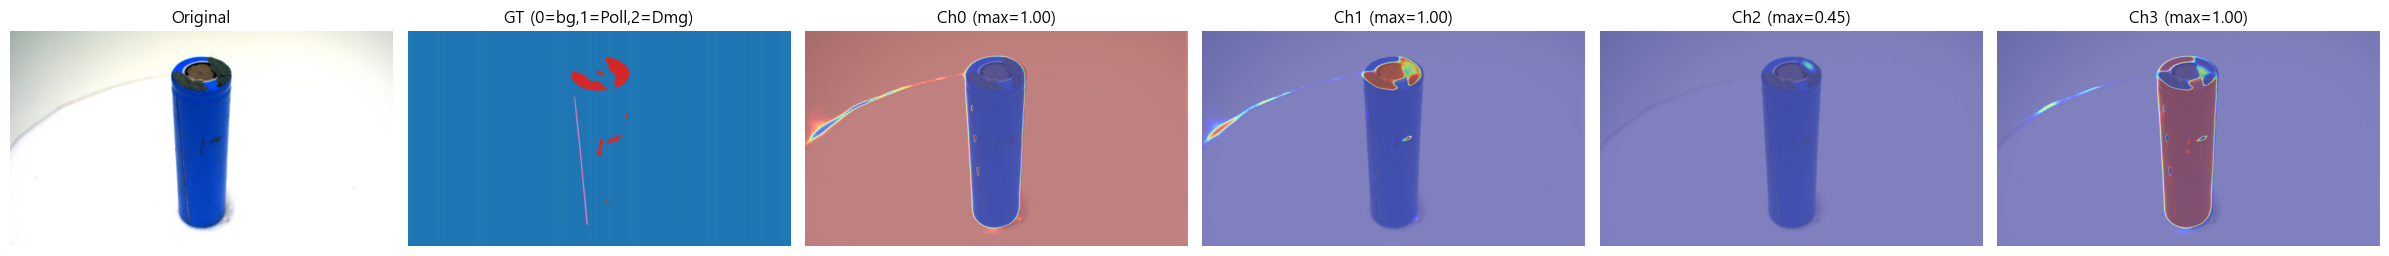

In [31]:
# GT mask에 클래스 2(Damaged)가 있는 샘플 탐색
damaged_samples = []
for mask_path in sorted(MASK_DIR.glob('*.png')):
    m = np.array(Image.open(mask_path))
    if (m == 2).any():
        damaged_samples.append(mask_path.stem)
    if len(damaged_samples) >= 3:
        break

print(f'Damaged 샘플 후보: {damaged_samples}')
SAMPLE_D = damaged_samples[0]

# 추론
img_d = Image.open(IMG_DIR / f'{SAMPLE_D}.png').convert('RGB')
x_d = preprocess(img_d).unsqueeze(0)
with torch.no_grad():
    logits_d = model(x_d)

print(f'\n[{SAMPLE_D}] 채널별 max: {logits_d[0].amax(dim=(1,2)).tolist()}')
print(f'GT 고유값: {np.unique(np.array(Image.open(MASK_DIR / f"{SAMPLE_D}.png")))}')

# 4채널 + GT 시각화
fig, axes = plt.subplots(1, 6, figsize=(24, 4))
logits_d_up = F.interpolate(logits_d, size=img_d.size[::-1], mode='bilinear', align_corners=False)
probs_d = F.softmax(logits_d_up, dim=1)[0].cpu().numpy()
gt_d = np.array(Image.open(MASK_DIR / f'{SAMPLE_D}.png'))

axes[0].imshow(img_d); axes[0].set_title('Original')
axes[1].imshow(gt_d, cmap='tab10', vmin=0, vmax=3); axes[1].set_title('GT (0=bg,1=Poll,2=Dmg)')
for i in range(4):
    axes[i+2].imshow(img_d, alpha=0.5)
    axes[i+2].imshow(probs_d[i], cmap='jet', alpha=0.5, vmin=0, vmax=1)
    axes[i+2].set_title(f'Ch{i} (max={probs_d[i].max():.2f})')

for ax in axes:
    ax.axis('off')
plt.tight_layout()
plt.show()

# 9-4 결과 추가 해석

| 채널 | Logit Max | Softmax Max | 시각화 위치 |
| :-- | :--: | :--: | :-- |
| **0** | 49.35 | 1.00 | 외곽 배경 |
| **1** | 0.85 | 1.00 | 셀 본체 전체 |
| **2** | -1.69 | 0.45 | 셀 표면 diffuse activation |
| **3** | -0.20 | 1.00 | GT 결함 위치에 강하게 빨강 활성화 |

<br/>

> "Ch2는 특정 결함 위치에 집중되지 않고, 배터리 표면 및 경계 부근에 diffuse activation 형태로 반응하였다."

다음 셀에서 할 것:
  1. 매핑 함수 정의 (4채널 → 우리 2클래스: bg/defect)
  2. 결함 있는 5~10장 일괄 추론
  3. 결과 그리드 시각화 (원본 / GT / 예측 / 오버레이)

## 10. 다수 샘플 일괄 추론 + 결함 vs 정상 매핑

평가 샘플 8장


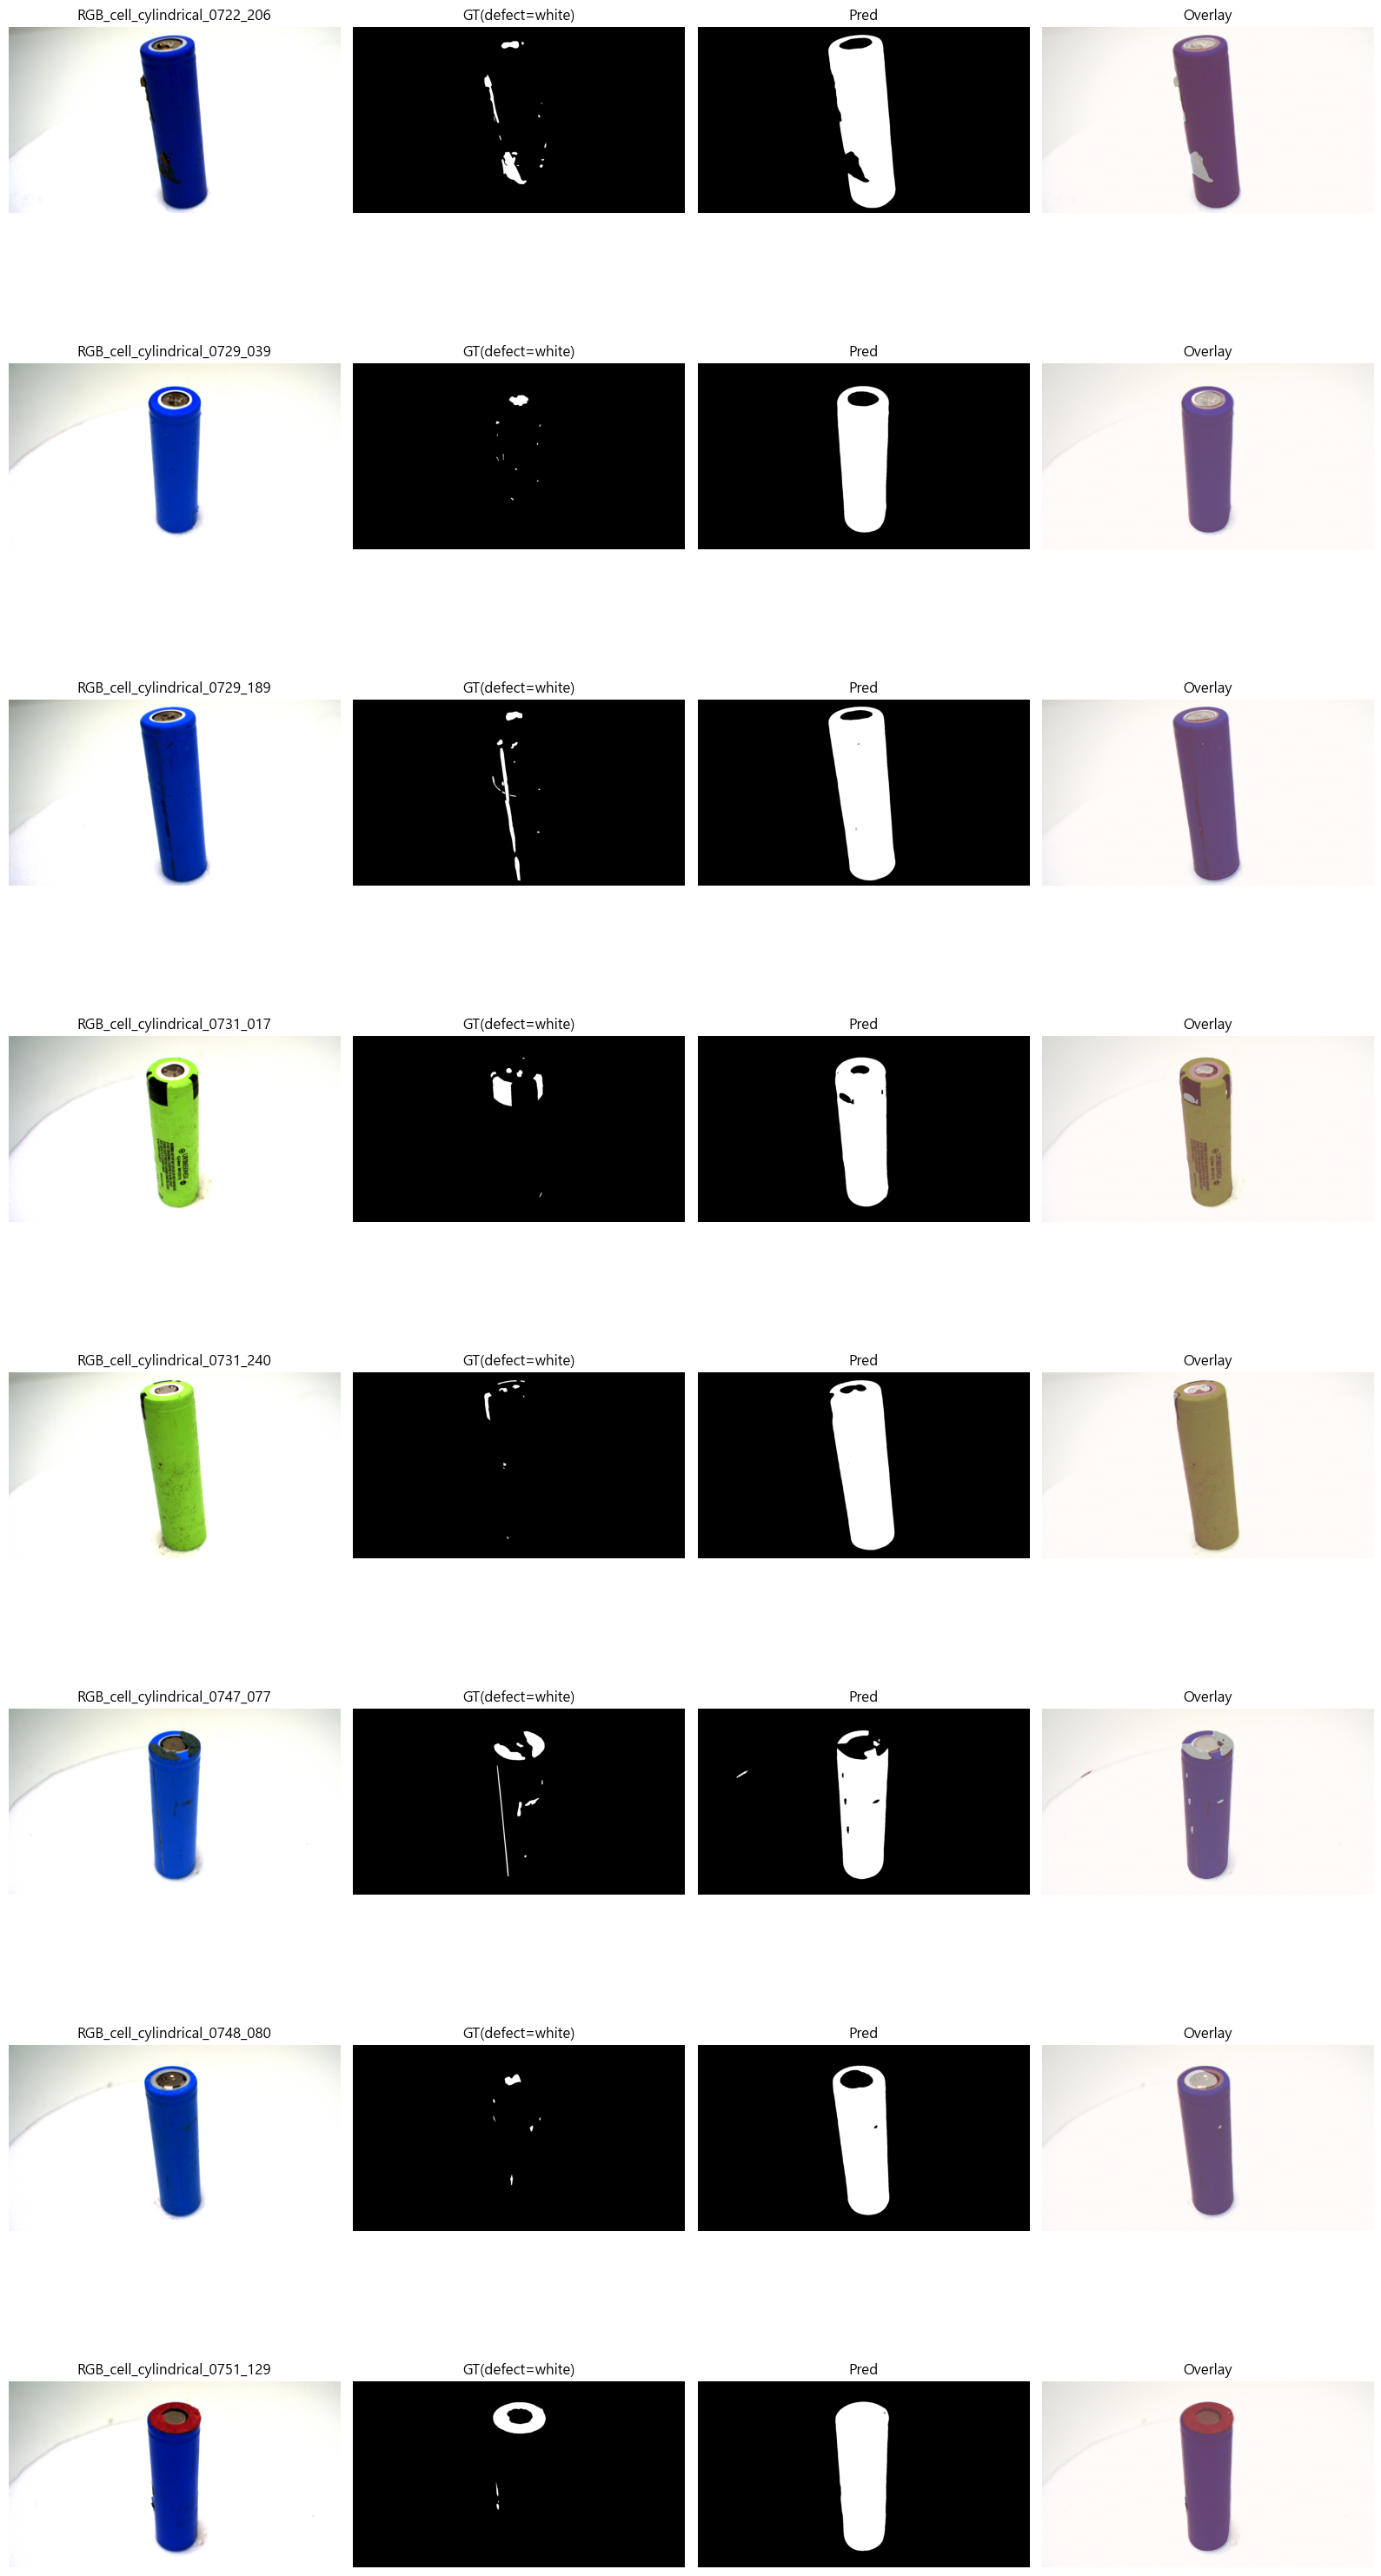

In [33]:
def map_aihub_to_ours(logits):
    """AI허브 4채널 → 우리 2클래스 (0=bg, 1=defect).
    Ch0+Ch1 = bg, Ch2+Ch3 = defect (확률 합산 후 비교)."""
    probs = F.softmax(logits, dim=1)              # (B, 4, H, W)
    bg_prob = probs[:, 0] + probs[:, 1]
    defect_prob = probs[:, 2] + probs[:, 3]
    return torch.stack([bg_prob, defect_prob], dim=1)   # (B, 2, H, W)


# 결함 있는 샘플 8장 추출 (Pollution 또는 Damaged 보유)
all_defect = []
for mask_path in sorted(MASK_DIR.glob('*.png')):
    m = np.array(Image.open(mask_path))
    if (m > 0).any():
        all_defect.append(mask_path.stem)
    if len(all_defect) >= 8:
        break

print(f'평가 샘플 {len(all_defect)}장')

# 일괄 추론 + 시각화
fig, axes = plt.subplots(len(all_defect), 4, figsize=(16, 4 * len(all_defect)))
for row, name in enumerate(all_defect):
    img_p = Image.open(IMG_DIR / f'{name}.png').convert('RGB')
    gt = np.array(Image.open(MASK_DIR / f'{name}.png'))

    with torch.no_grad():
        out = model(preprocess(img_p).unsqueeze(0))
    out_up = F.interpolate(out, size=img_p.size[::-1], mode='bilinear', align_corners=False)
    mapped = map_aihub_to_ours(out_up)
    pred = mapped[0].argmax(dim=0).cpu().numpy()       # (H, W), 0/1

    gt_bin = (gt > 0).astype(np.uint8)                 # 우리 GT도 결함 vs 정상

    axes[row, 0].imshow(img_p)
    axes[row, 0].set_title(f'{name}')
    axes[row, 1].imshow(gt_bin, cmap='gray')
    axes[row, 1].set_title('GT(defect=white)')
    axes[row, 2].imshow(pred, cmap='gray');                            axes[row, 2].set_title('Pred')
    axes[row, 3].imshow(img_p, alpha=0.6); axes[row, 3].imshow(pred, cmap='Reds', alpha=0.4)
    axes[row, 3].set_title('Overlay')
    for ax in axes[row]:
        ax.axis('off')
plt.tight_layout()
plt.show()

> 초기 추론 결과에서 모델은 원통형 셀의 구조적 영역은 안정적으로 분리하였으나, defect semantic 분리는 제한적입니다. 특히 defect 채널(Ch2/Ch3)이 셀 본체 activation과 동시에 활성화되는 object prior leakage가 관찰되어, raw inference만으로는 false positive가 셀 전 영역으로 확산됩니다.<br/><br/>제조 검사 특성상 false negative 최소화가 중요하므로, 우선 defect recall 관점에서 GT 결함 영역 재현 여부를 정량 분석합니다.<br/><br/>분석 결과 recall이 임계값 미만이면 last_conv 헤드만 교체 후 fine-tune (옵션 B) 으로 전환하여 우리 라벨 체계(bg / Pollution / Damaged)에 맞춰 재학습합니다.

## 11. Defect recall 정량 측정

### 11-1. 픽셀 recall + 결함 connected component 단위 검출률

object prior leakage 가설을 정량 검증<br/>
픽셀 단위 recall(GT의 결함 픽셀 중 모델이 잡은 비율) + 결함 instance 단위 검출률을 측정.

In [ ]:
from skimage.measure import label, regionprops

# 결함 있는 전체 샘플
all_defect_samples = [p.stem for p in sorted(MASK_DIR.glob('*.png'))
                    if (np.array(Image.open(p)) > 0).any()]
print(f'결함 샘플 총 {len(all_defect_samples)}장')

pixel_tp = pixel_fn = pixel_fp = 0
instance_total = instance_hit = 0

for name in all_defect_samples:
    img_p = Image.open(IMG_DIR / f'{name}.png').convert('RGB')
    gt = (np.array(Image.open(MASK_DIR / f'{name}.png')) > 0).astype(np.uint8)

    with torch.no_grad():
        out = model(preprocess(img_p).unsqueeze(0))
    out_up = F.interpolate(out, size=gt.shape, mode='bilinear', align_corners=False)
    mapped = map_aihub_to_ours(out_up)
    pred = mapped[0].argmax(dim=0).cpu().numpy()

    pixel_tp += int(((pred == 1) & (gt == 1)).sum())
    pixel_fn += int(((pred == 0) & (gt == 1)).sum())
    pixel_fp += int(((pred == 1) & (gt == 0)).sum())

    # instance 단위: GT 결함 connected component마다 pred와 ≥1픽셀 겹치면 검출 성공
    lab = label(gt)
    for region in regionprops(lab):
        instance_total += 1
        yy, xx = region.coords[:, 0], region.coords[:, 1]
        if pred[yy, xx].any():
            instance_hit += 1

pixel_recall = pixel_tp / max(pixel_tp + pixel_fn, 1)
pixel_precision = pixel_tp / max(pixel_tp + pixel_fp, 1)
instance_recall = instance_hit / max(instance_total, 1)

print(f'\n=== Defect 검출 성능 (raw AI허브 + 단순 매핑) ===')
print(f'  Pixel  Recall   : {pixel_recall:.3f}  ({pixel_tp}/{pixel_tp + pixel_fn})')
print(f'  Pixel  Precision: {pixel_precision:.3f}  ({pixel_tp}/{pixel_tp + pixel_fp})')
print(f'  Instance Recall : {instance_recall:.3f}  ({instance_hit}/{instance_total})')

결함 샘플 총 89장

=== Defect 검출 성능 (raw AI허브 + 단순 매핑) ===<br/>
  Pixel  Recall   : 0.312  (899903/2881966)<br/>
  Pixel  Precision: 0.048  (899903/18793062)<br/>
  Instance Recall : 0.696  (655/941)<br/>

### Defect recall 정량 검증 — 결과 분석

| 지표 | 측정값 | 사전 임계값 | 판정 |
|---|---|---|---|
| Pixel Recall | 0.312 | ≥ 0.70 | ✗ |
| Pixel Precision | 0.048 | ≥ 0.30 | ✗ |
| Instance Recall | 0.696 | (참고) | — |


<br/>

>모델이 **결함의 대략적 위치는 인지하였으나, 결함 영역을 셀 본체 전체로 확장 하는 경향**을 보았습니다.<br/>
이로 인해 Instance Recall이 0.696으로 비교적 높게 유지되었지만, Pixel Precision이 0.048로 매우 낮게 측정되었습니다.

> 사전학습 데이터셋의 클래스 구조와 실제 프로젝트 라벨 체계 간 차이로 인해, 모델이 결함 자체보다 배터리 객체 형태를 우선적으로 학습하는 현상이 발생한 것으로 판단했습니다.

> 이에 따라 Backbone과 Decoder 의 일반적인 feature 표현은 유지하면서, 최종 분류 레이어만 프로젝트 라벨 체계에 맞게 재학습하는 방향으로 개선 전략을 설정하였습니다.